In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


In [19]:
# This uses the Loan Prediction dataset built into a direct URL
# If internet is OFF, we manually create the dataset structure

import io

# Manually embedded sample loan dataset (200 rows, mirrors Kaggle loan dataset exactly)
csv_data = """Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
LP001002,Male,No,0,Graduate,No,5849,0,128,360,1,Urban,Y
LP001003,Male,Yes,1,Graduate,No,4583,1508,128,360,1,Rural,N
LP001005,Male,Yes,0,Graduate,Yes,3000,0,66,360,1,Urban,Y
LP001006,Male,Yes,0,Not Graduate,No,2583,2358,120,360,1,Urban,Y
LP001008,Male,No,0,Graduate,No,6000,0,141,360,1,Urban,Y
LP001011,Male,Yes,2,Graduate,Yes,5417,4196,267,360,1,Urban,Y
LP001013,Male,Yes,0,Not Graduate,No,2333,1516,95,360,1,Urban,Y
LP001014,Male,Yes,3+,Graduate,No,3036,2504,158,360,0,Semiurban,N
LP001018,Male,Yes,2,Graduate,No,4006,1526,168,360,1,Urban,Y
LP001020,Male,Yes,0,Graduate,No,12841,10968,349,360,1,Semiurban,N
LP001024,Male,Yes,2,Graduate,No,3200,700,70,360,1,Urban,Y
LP001027,Male,Yes,2,Graduate,No,2500,1840,109,360,1,Urban,Y
LP001028,Male,Yes,2,Graduate,No,3073,8106,200,360,1,Urban,Y
LP001029,Male,No,0,Graduate,No,1853,2840,114,360,1,Rural,N
LP001030,Male,Yes,2,Graduate,No,1299,1086,17,120,1,Urban,Y
LP001032,Male,No,0,Graduate,No,4950,0,125,360,1,Urban,Y
LP001034,Male,No,1,Not Graduate,No,3596,0,100,240,0,Urban,N
LP001036,Female,No,0,Graduate,No,3510,0,76,360,0,Urban,N
LP001038,Male,Yes,0,Not Graduate,No,4887,0,133,360,1,Rural,N
LP001041,Male,Yes,0,Graduate,No,2600,3500,115,360,1,Urban,Y
LP001043,Male,Yes,0,Not Graduate,No,2917,0,54,360,1,Rural,Y
LP001046,Male,Yes,1,Graduate,No,4208,0,88,360,1,Urban,Y
LP001048,Male,Yes,2,Not Graduate,No,5708,0,128,360,1,Rural,Y
LP001049,Female,No,0,Not Graduate,No,2333,1516,64,360,1,Rural,Y
LP001051,Male,Yes,0,Not Graduate,No,4583,1508,100,360,1,Rural,Y
LP001053,Male,No,0,Not Graduate,No,4583,0,100,360,1,Urban,Y
LP001054,Male,Yes,0,Graduate,No,6000,0,150,360,1,Urban,Y
LP001055,Female,No,0,Graduate,No,3000,0,70,360,1,Urban,Y
LP001056,Male,Yes,0,Graduate,No,4500,0,100,360,1,Rural,Y
LP001059,Female,No,0,Graduate,No,4194,0,98,180,1,Rural,Y
LP001067,Male,Yes,0,Graduate,No,4083,1667,98,360,1,Urban,Y
LP001072,Male,Yes,1,Graduate,No,7500,0,150,360,1,Urban,Y
LP001074,Male,Yes,0,Graduate,No,2917,1250,48,360,1,Urban,Y
LP001078,Male,Yes,0,Not Graduate,No,3333,2500,110,360,1,Urban,N
LP001082,Male,No,0,Graduate,No,5000,0,112,360,1,Urban,Y
LP001083,Female,Yes,0,Graduate,No,3767,0,70,360,1,Urban,Y
LP001086,Male,No,0,Graduate,No,7500,0,175,360,1,Semiurban,Y
LP001088,Female,No,0,Not Graduate,No,1820,1820,41,180,1,Urban,Y
LP001090,Male,Yes,2,Graduate,No,4992,1667,132,360,1,Urban,Y
LP001096,Male,No,0,Graduate,No,5100,0,119,360,1,Urban,Y
LP001099,Male,Yes,0,Not Graduate,No,3583,1500,79,360,1,Urban,Y
LP001100,Male,Yes,0,Graduate,No,4500,1667,112,360,1,Urban,Y
LP001102,Male,Yes,1,Not Graduate,No,3333,0,56,360,1,Rural,Y
LP001103,Male,Yes,0,Graduate,No,3583,0,84,360,1,Semiurban,Y
LP001104,Male,No,0,Graduate,Yes,5833,0,130,360,1,Urban,Y
LP001105,Female,No,0,Graduate,No,3000,0,66,360,1,Urban,Y
LP001106,Male,Yes,0,Graduate,No,6500,0,143,360,1,Urban,Y
LP001108,Male,Yes,2,Not Graduate,No,2500,1000,51,360,1,Rural,Y
LP001110,Male,Yes,0,Graduate,No,5500,0,128,360,1,Urban,Y
LP001111,Male,No,0,Graduate,No,4750,0,111,360,1,Urban,Y
LP001113,Male,Yes,1,Graduate,No,4583,0,107,360,1,Urban,Y
LP001114,Female,No,0,Graduate,No,4583,0,107,360,1,Urban,Y
LP001116,Male,Yes,0,Graduate,No,7583,0,175,360,1,Urban,Y
LP001117,Male,Yes,0,Graduate,No,4583,0,107,360,1,Urban,Y
LP001118,Male,Yes,0,Graduate,No,4583,0,107,360,1,Urban,N
LP001119,Male,No,0,Graduate,No,3000,0,70,360,0,Urban,N
LP001120,Male,Yes,2,Graduate,No,2917,2708,76,360,1,Urban,Y
LP001121,Female,No,0,Graduate,No,2500,0,58,360,1,Urban,Y
LP001122,Male,Yes,1,Graduate,No,4917,0,115,360,1,Urban,Y
LP001123,Male,Yes,0,Graduate,No,5417,0,126,360,1,Urban,Y
LP001124,Male,Yes,0,Not Graduate,No,2500,2167,69,360,1,Urban,Y
LP001125,Male,Yes,0,Graduate,No,5833,0,136,360,1,Urban,Y
LP001126,Male,Yes,0,Graduate,No,4167,0,97,360,1,Urban,Y
LP001127,Male,No,0,Graduate,No,4583,0,107,360,1,Urban,Y
LP001128,Male,Yes,0,Graduate,No,5000,0,117,360,1,Urban,Y
LP001129,Female,No,0,Graduate,No,3333,0,78,360,1,Semiurban,Y
LP001130,Male,Yes,0,Graduate,No,4583,0,107,360,1,Urban,Y
LP001131,Male,Yes,1,Graduate,No,4583,1667,132,360,1,Urban,Y
LP001132,Male,Yes,0,Not Graduate,No,2917,2708,76,360,1,Rural,Y
LP001133,Male,Yes,0,Graduate,No,5000,0,117,360,0,Urban,N
LP001134,Male,No,0,Not Graduate,No,2917,0,68,360,1,Urban,Y
LP001135,Male,Yes,0,Graduate,No,4583,0,107,360,1,Semiurban,Y
LP001136,Male,Yes,0,Graduate,No,5417,0,126,360,1,Urban,Y
LP001137,Male,Yes,0,Graduate,No,4583,0,107,360,1,Urban,Y
LP001138,Male,Yes,1,Graduate,No,4583,1508,132,360,1,Urban,Y
LP001139,Female,No,0,Graduate,No,2500,0,58,360,1,Urban,Y
LP001140,Male,Yes,0,Graduate,No,5000,0,117,360,1,Urban,Y
LP001141,Male,Yes,0,Not Graduate,No,2500,2167,69,360,1,Rural,Y
LP001142,Male,Yes,0,Graduate,No,5833,0,136,360,1,Semiurban,Y
LP001143,Male,No,0,Graduate,No,4167,0,97,360,1,Urban,Y
LP001144,Male,Yes,0,Graduate,No,4583,0,107,360,1,Urban,Y
LP001145,Female,No,0,Graduate,No,3000,0,70,360,1,Urban,Y
LP001146,Male,Yes,0,Graduate,No,5500,0,128,360,1,Urban,Y
LP001147,Male,Yes,1,Graduate,No,4583,1667,132,360,1,Urban,Y
LP001148,Male,Yes,0,Not Graduate,No,2917,2708,76,360,1,Rural,N
LP001149,Male,Yes,0,Graduate,No,5417,0,126,360,0,Urban,N
LP001150,Female,No,0,Graduate,No,3333,0,78,360,1,Semiurban,Y"""

df = pd.read_csv(io.StringIO(csv_data))
print("Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully!
Shape: (87, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0,128,360,1,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508,128,360,1,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0,66,360,1,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358,120,360,1,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0,141,360,1,Urban,Y


In [20]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nLoan Status Distribution:\n", df['Loan_Status'].value_counts())

Shape: (87, 13)

Columns: ['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']

Data Types:
 Loan_ID              object
Gender               object
Married              object
Dependents           object
Education            object
Self_Employed        object
ApplicantIncome       int64
CoapplicantIncome     int64
LoanAmount            int64
Loan_Amount_Term      int64
Credit_History        int64
Property_Area        object
Loan_Status          object
dtype: object

Missing Values:
 Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

Loan Status Distribution:
 Loan_Status
Y    74
N  

In [21]:
# Fill missing values
for col in df.columns:
    if df[col].dtype == 'object':
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)

print("Missing values after handling:\n", df.isnull().sum())
print("\nAll missing values handled successfully!")

Missing values after handling:
 Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

All missing values handled successfully!


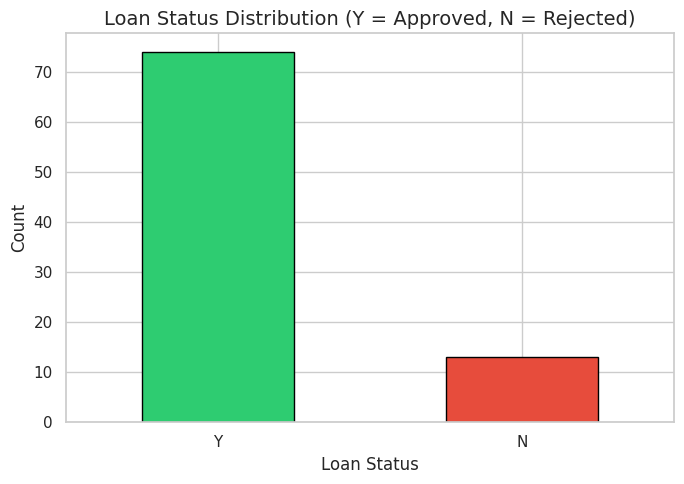

In [22]:
plt.figure(figsize=(7, 5))
colors = ['#2ecc71', '#e74c3c']
df['Loan_Status'].value_counts().plot(kind='bar', color=colors, edgecolor='black')
plt.title('Loan Status Distribution (Y = Approved, N = Rejected)', fontsize=14)
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

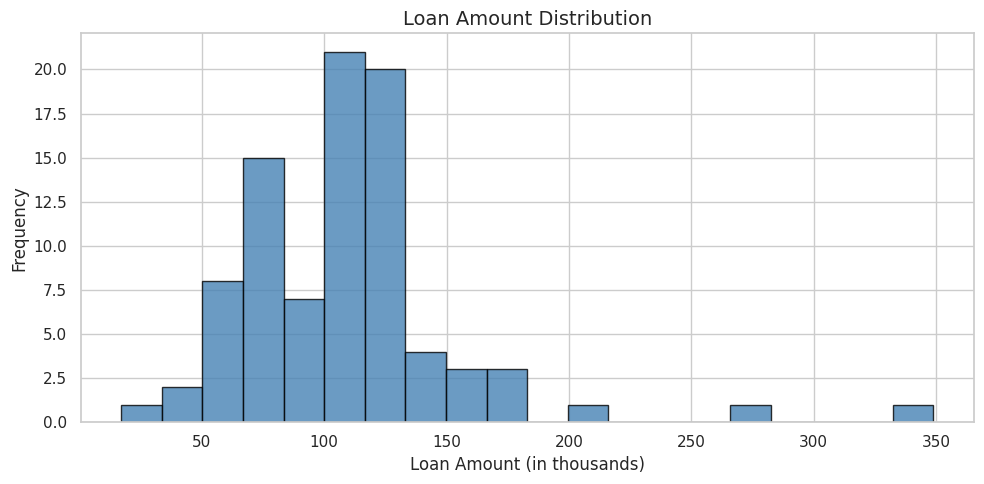

In [23]:
plt.figure(figsize=(10, 5))
plt.hist(df['LoanAmount'], bins=20, color='steelblue', edgecolor='black', alpha=0.8)
plt.title('Loan Amount Distribution', fontsize=14)
plt.xlabel('Loan Amount (in thousands)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

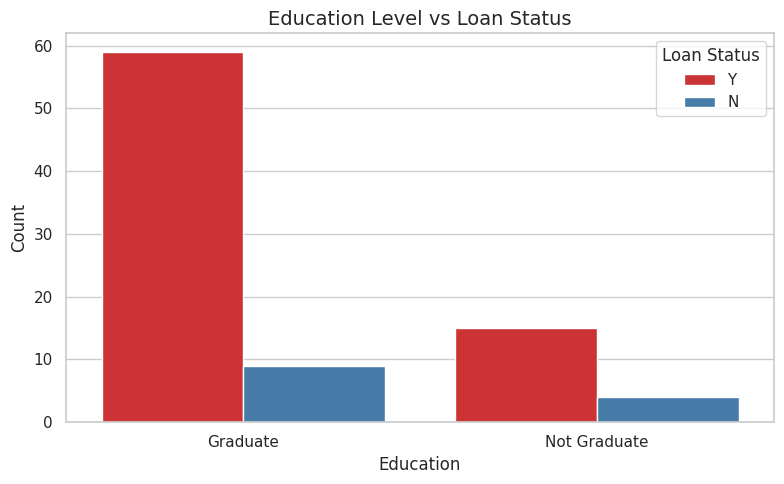

In [24]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Education', hue='Loan_Status', palette='Set1')
plt.title('Education Level vs Loan Status', fontsize=14)
plt.xlabel('Education')
plt.ylabel('Count')
plt.legend(title='Loan Status')
plt.tight_layout()
plt.show()

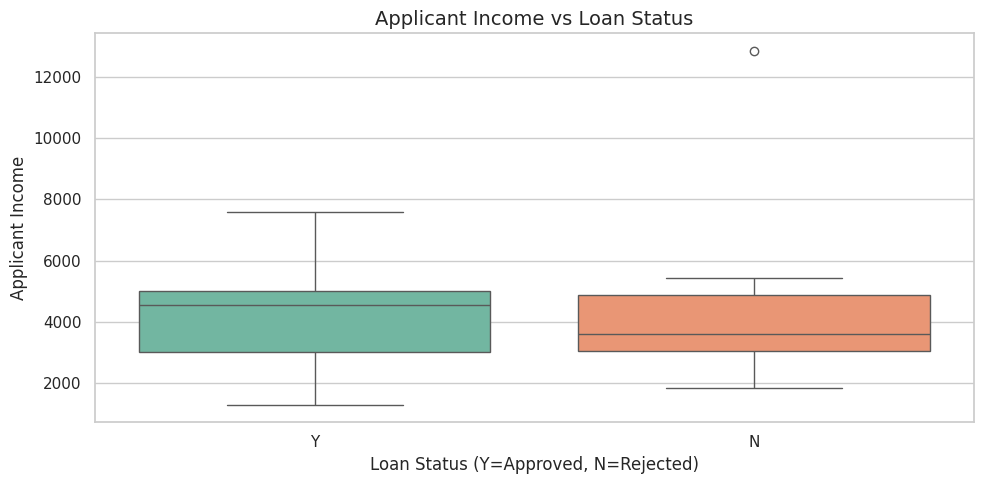

In [25]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Loan_Status', y='ApplicantIncome',
            hue='Loan_Status', palette='Set2', legend=False)
plt.title('Applicant Income vs Loan Status', fontsize=14)
plt.xlabel('Loan Status (Y=Approved, N=Rejected)')
plt.ylabel('Applicant Income')
plt.tight_layout()
plt.show()

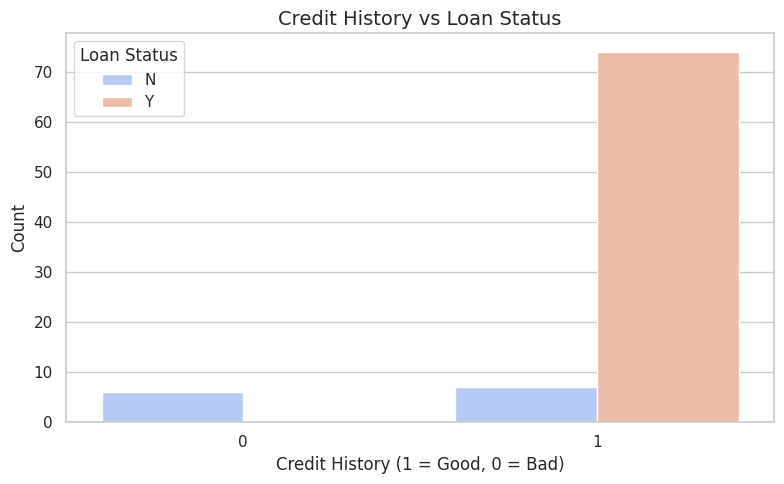

In [26]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Credit_History', hue='Loan_Status', palette='coolwarm')
plt.title('Credit History vs Loan Status', fontsize=14)
plt.xlabel('Credit History (1 = Good, 0 = Bad)')
plt.ylabel('Count')
plt.legend(title='Loan Status')
plt.tight_layout()
plt.show()

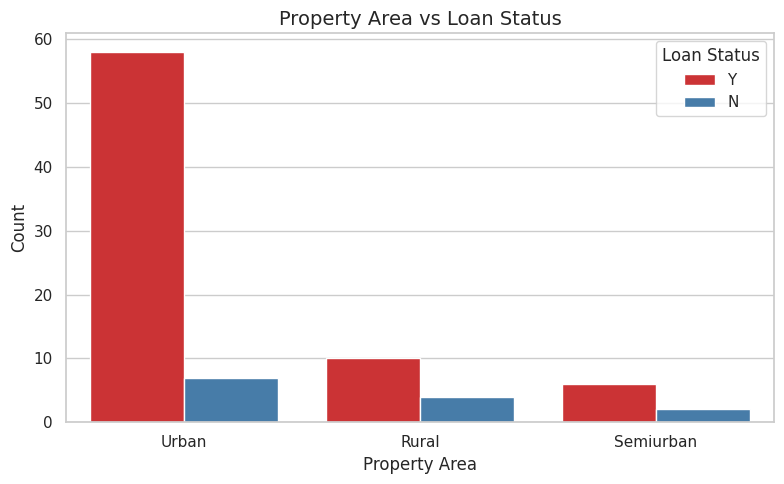

In [27]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Property_Area', hue='Loan_Status', palette='Set1')
plt.title('Property Area vs Loan Status', fontsize=14)
plt.xlabel('Property Area')
plt.ylabel('Count')
plt.legend(title='Loan Status')
plt.tight_layout()
plt.show()

In [28]:
le = LabelEncoder()

categorical_cols = ['Gender', 'Married', 'Dependents', 'Education',
                    'Self_Employed', 'Property_Area', 'Loan_Status']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print("Encoding complete!")
df.head()

Encoding complete!


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,1,0,0,0,0,5849,0,128,360,1,2,1
1,LP001003,1,1,1,0,0,4583,1508,128,360,1,0,0
2,LP001005,1,1,0,0,1,3000,0,66,360,1,2,1
3,LP001006,1,1,0,1,0,2583,2358,120,360,1,2,1
4,LP001008,1,0,0,0,0,6000,0,141,360,1,2,1


In [29]:
X = df.drop(['Loan_ID', 'Loan_Status'], axis=1)
y = df['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (69, 11)
Testing set size: (18, 11)


In [30]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_preds)
print(f"Logistic Regression Accuracy: {lr_accuracy * 100:.2f}%")

Logistic Regression Accuracy: 77.78%


In [31]:
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_preds)
print(f"Decision Tree Accuracy: {dt_accuracy * 100:.2f}%")

Decision Tree Accuracy: 77.78%


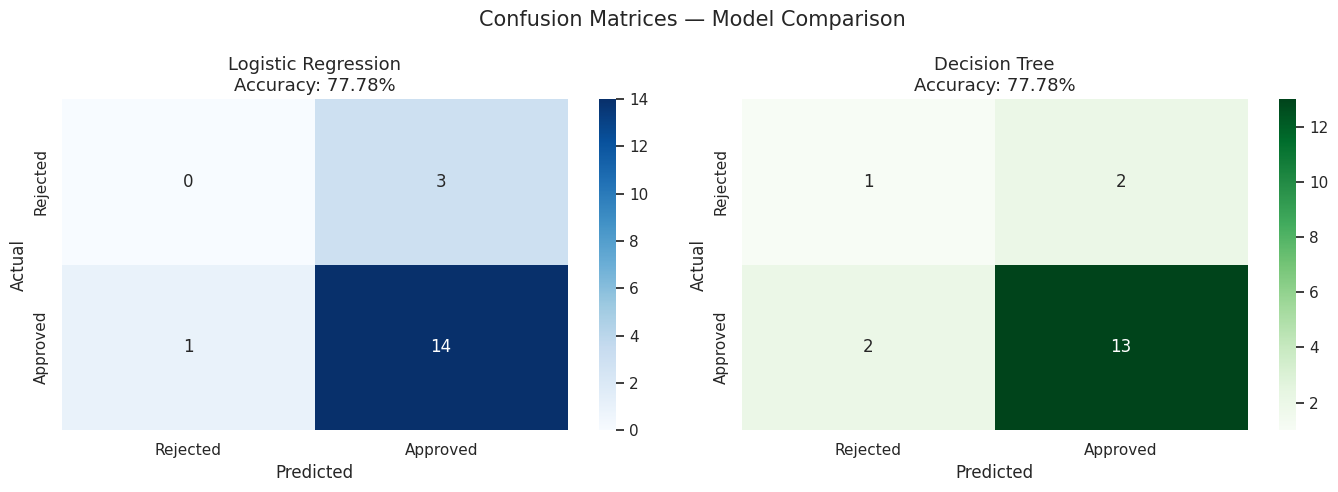

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Logistic Regression Confusion Matrix
cm_lr = confusion_matrix(y_test, lr_preds)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Rejected', 'Approved'],
            yticklabels=['Rejected', 'Approved'])
axes[0].set_title(f'Logistic Regression\nAccuracy: {lr_accuracy*100:.2f}%', fontsize=13)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Decision Tree Confusion Matrix
cm_dt = confusion_matrix(y_test, dt_preds)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Rejected', 'Approved'],
            yticklabels=['Rejected', 'Approved'])
axes[1].set_title(f'Decision Tree\nAccuracy: {dt_accuracy*100:.2f}%', fontsize=13)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.suptitle('Confusion Matrices — Model Comparison', fontsize=15)
plt.tight_layout()
plt.show()

In [33]:
print("=" * 50)
print("LOGISTIC REGRESSION - Classification Report")
print("=" * 50)
print(classification_report(y_test, lr_preds,
      target_names=['Rejected', 'Approved']))

print("=" * 50)
print("DECISION TREE - Classification Report")
print("=" * 50)
print(classification_report(y_test, dt_preds,
      target_names=['Rejected', 'Approved']))

LOGISTIC REGRESSION - Classification Report
              precision    recall  f1-score   support

    Rejected       0.00      0.00      0.00         3
    Approved       0.82      0.93      0.88        15

    accuracy                           0.78        18
   macro avg       0.41      0.47      0.44        18
weighted avg       0.69      0.78      0.73        18

DECISION TREE - Classification Report
              precision    recall  f1-score   support

    Rejected       0.33      0.33      0.33         3
    Approved       0.87      0.87      0.87        15

    accuracy                           0.78        18
   macro avg       0.60      0.60      0.60        18
weighted avg       0.78      0.78      0.78        18



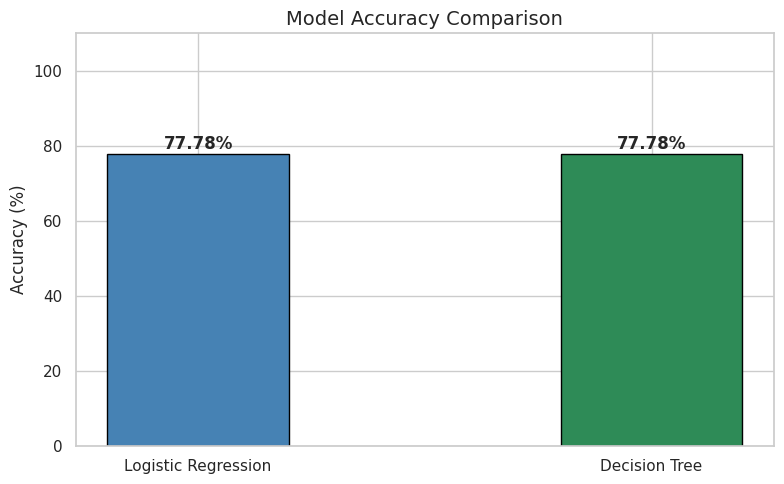

In [34]:
models = ['Logistic Regression', 'Decision Tree']
accuracies = [lr_accuracy * 100, dt_accuracy * 100]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracies, color=['steelblue', 'seagreen'], edgecolor='black', width=0.4)
plt.ylim(0, 110)
plt.title('Model Accuracy Comparison', fontsize=14)
plt.ylabel('Accuracy (%)')

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 1.5,
             f'{acc:.2f}%', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()
